# Notebook 2: Exploratory Data Analysis - Climate Trends

This notebook explores the cleaned climate dataset to identify temperature patterns, rainfall trends, seasonal behavior, and climate risk indicators across Myanmar and Singapore cities.

The main goal is to extract meaningful insights that can later be used in the Streamlit dashboard.

In [1]:
# import the libraries
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt

In [2]:
# Load the dataset
df = pd.read_csv("C:/Projects/15_Climate_Risk_weather_Trends/data/processed/climate_weather_processed.csv")
df.head()

,date,temperature_avg,temperature_max,temperature_min,rainfall,humidity,wind_speed,solar_radiation,city,country,...,season,heat_risk_day,very_hot_day,heavy_rain_day,dry_day,temperature_range,rainfall_category,temperature_category,daily_climate_risk_score,risk_level
0,2020-01-01,22.56,29.21,17.90,4.79,64.14,2.21,9.34,Mandalay,Myanmar,...,Cool Season,0,0,0,0,11.31,Light Rain,Normal,0,Low
1,2020-01-02,22.87,30.14,17.65,0.76,66.13,2.17,9.82,Mandalay,Myanmar,...,Cool Season,0,0,0,1,12.49,Light Rain,Warm,10,Low
2,2020-01-03,21.56,26.78,17.90,9.95,75.17,2.04,9.07,Mandalay,Myanmar,...,Cool Season,0,0,0,0,8.88,Light Rain,Normal,0,Low
3,2020-01-04,21.44,27.62,18.01,6.08,79.23,2.31,9.21,Mandalay,Myanmar,...,Cool Season,0,0,0,0,9.61,Light Rain,Normal,0,Low
4,2020-01-05,21.10,26.91,17.26,9.39,79.46,3.25,10.89,Mandalay,Myanmar,...,Cool Season,0,0,0,0,9.65,Light Rain,Normal,0,Low


In [3]:
# Dataset Overview
print("Dataset Shape:", df.shape)
print("Columns:")
print(df.columns.tolist())

Dataset Shape: (8768, 27)
Columns:
['date', 'temperature_avg', 'temperature_max', 'temperature_min', 'rainfall', 'humidity', 'wind_speed', 'solar_radiation', 'city', 'country', 'latitude', 'longitude', 'year', 'month', 'month_name', 'day', 'day_of_year', 'season', 'heat_risk_day', 'very_hot_day', 'heavy_rain_day', 'dry_day', 'temperature_range', 'rainfall_category', 'temperature_category', 'daily_climate_risk_score', 'risk_level']


In [4]:
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 8768 entries, 0 to 8767
Data columns (total 27 columns):
 #   Column                    Non-Null Count  Dtype  
---  ------                    --------------  -----  
 0   date                      8768 non-null   object 
 1   temperature_avg           8768 non-null   float64
 2   temperature_max           8768 non-null   float64
 3   temperature_min           8768 non-null   float64
 4   rainfall                  8768 non-null   float64
 5   humidity                  8768 non-null   float64
 6   wind_speed                8768 non-null   float64
 7   solar_radiation           8768 non-null   float64
 8   city                      8768 non-null   object 
 9   country                   8768 non-null   object 
 10  latitude                  8768 non-null   float64
 11  longitude                 8768 non-null   float64
 12  year                      8768 non-null   int64  
 13  month                     8768 non-null   int64  
 14  month_na

In [6]:
# Convert Date column
df["date"] = pd.to_datetime(df["date"])

print("Minimum date:", df["date"].min())
print("Maximum date:", df["date"].max())

Minimum date: 2020-01-01 00:00:00
Maximum date: 2025-12-31 00:00:00


## 1. Yearly Average Temperature Trend by City

This section analyzes how the average temperature changes over time for each city.

This plot helps identify whether cities are becoming warmer across the selected years.

In [14]:
yearly_temperature = df.groupby(["city", "year"], as_index=False).agg(
    avg_temperature=("temperature_avg", "mean")
)

yearly_temperature.head()

,city,year,avg_temperature
0,Mandalay,2020,27.176120
1,Mandalay,2021,27.799589
2,Mandalay,2022,27.526548
3,Mandalay,2023,28.016466
4,Mandalay,2024,27.834071


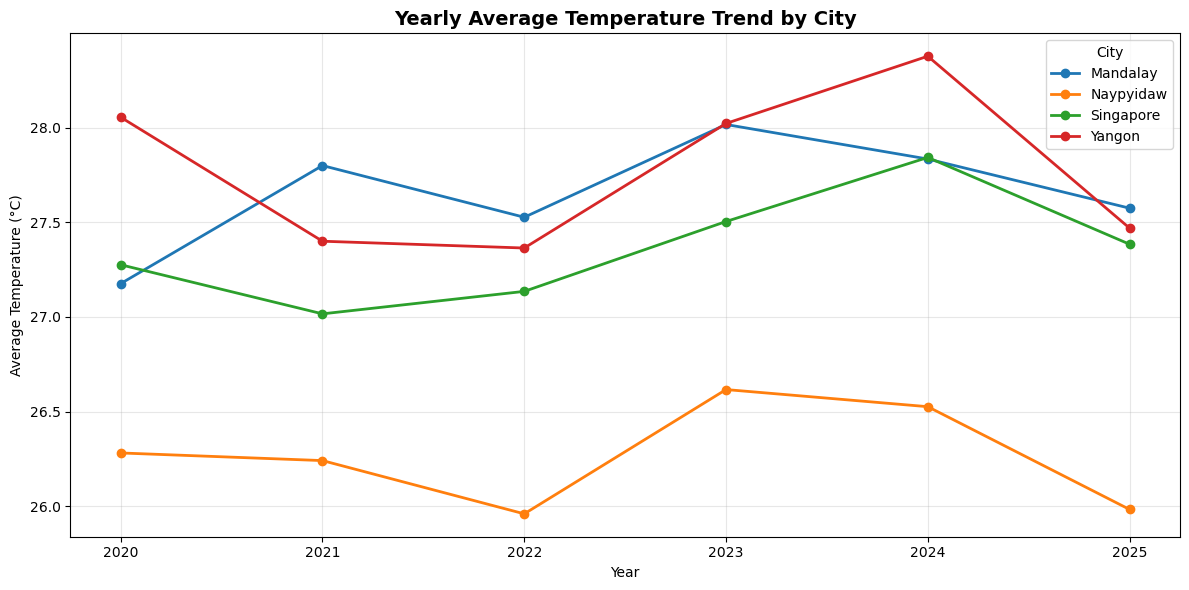

In [15]:
plt.figure(figsize=(12, 6))

for city in yearly_temperature["city"].unique():
    city_data = yearly_temperature[yearly_temperature["city"] == city]
    plt.plot(
        city_data["year"],
        city_data["avg_temperature"],
        marker="o",
        linewidth=2,
        label=city
    )

plt.title("Yearly Average Temperature Trend by City", fontsize=14, fontweight="bold")
plt.xlabel("Year")
plt.ylabel("Average Temperature (°C)")
plt.legend(title="City")
plt.grid(True, alpha=0.3)
plt.tight_layout()
plt.show()

## 2. Yearly Total Rainfall Trend by City

This section analyzes how total rainfall changes over time for each city.

This plot helps identify rainfall patterns, wetter years, and possible changes in precipitation behavior across selected cities.

In [16]:
yearly_rainfall = df.groupby(["city", "year"], as_index=False).agg(
    total_rainfall=("rainfall", "sum")
)

yearly_rainfall.head()

,city,year,total_rainfall
0,Mandalay,2020,470.39
1,Mandalay,2021,383.44
2,Mandalay,2022,425.89
3,Mandalay,2023,431.50
4,Mandalay,2024,484.03


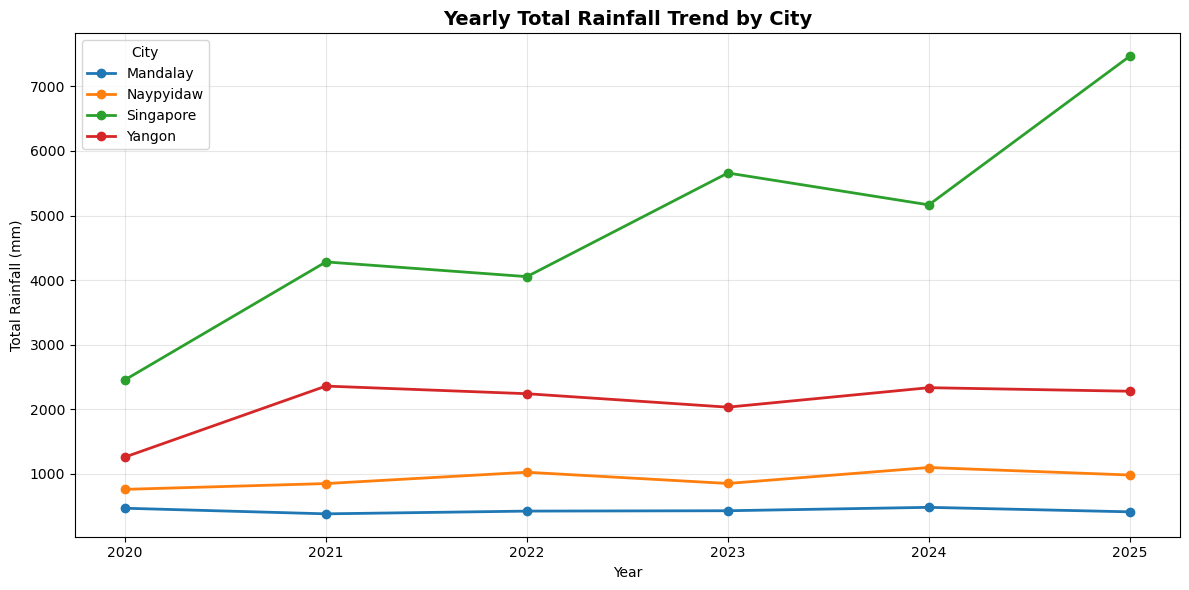

In [17]:
plt.figure(figsize=(12, 6))

for city in yearly_rainfall["city"].unique():
    city_data = yearly_rainfall[yearly_rainfall["city"] == city]
    plt.plot(
        city_data["year"],
        city_data["total_rainfall"],
        marker="o",
        linewidth=2,
        label=city
    )

plt.title("Yearly Total Rainfall Trend by City", fontsize=14, fontweight="bold")
plt.xlabel("Year")
plt.ylabel("Total Rainfall (mm)")
plt.legend(title="City")
plt.grid(True, alpha=0.3)
plt.tight_layout()
plt.show()

## 3. Monthly Rainfall Pattern by City

This section analyzes the monthly rainfall pattern for each city.

This plot helps identify seasonal rainfall behavior, rainy months, and dry months across selected cities.

In [18]:
monthly_rainfall = df.groupby(["city", "month", "month_name"], as_index=False).agg(
    avg_monthly_rainfall=("rainfall", "mean")
)

monthly_rainfall = monthly_rainfall.sort_values(by=["city", "month"])

monthly_rainfall.head()

,city,month,month_name,avg_monthly_rainfall
0,Mandalay,1,Jan,0.281828
1,Mandalay,2,Feb,0.325588
2,Mandalay,3,Mar,0.281183
3,Mandalay,4,Apr,0.664889
4,Mandalay,5,May,1.985968


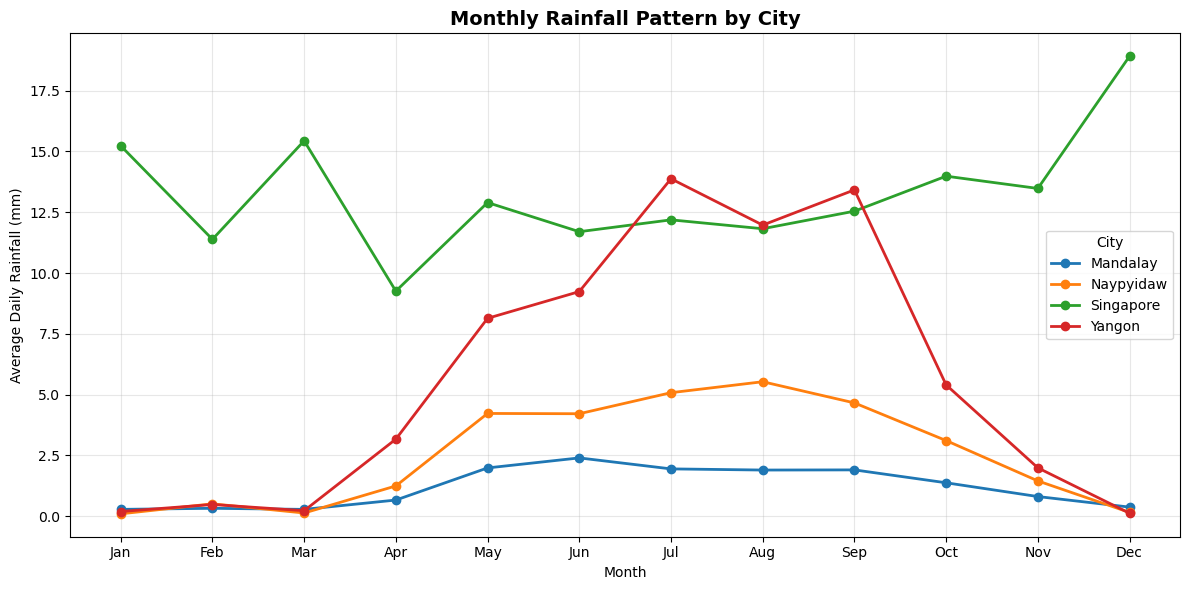

In [19]:
plt.figure(figsize=(12, 6))

for city in monthly_rainfall["city"].unique():
    city_data = monthly_rainfall[monthly_rainfall["city"] == city]
    plt.plot(
        city_data["month_name"],
        city_data["avg_monthly_rainfall"],
        marker="o",
        linewidth=2,
        label=city
    )

plt.title("Monthly Rainfall Pattern by City", fontsize=14, fontweight="bold")
plt.xlabel("Month")
plt.ylabel("Average Daily Rainfall (mm)")
plt.legend(title="City")
plt.grid(True, alpha=0.3)
plt.tight_layout()
plt.show()

## 4. Monthly Average Temperature Pattern by City

This section analyzes the average temperature pattern for each month.

This plot helps identify hotter months, cooler months, and seasonal temperature differences across selected cities.

In [20]:
monthly_temperature = df.groupby(["city", "month", "month_name"], as_index=False).agg(
    avg_monthly_temperature=("temperature_avg", "mean")
)

monthly_temperature = monthly_temperature.sort_values(by=["city", "month"])

monthly_temperature.head()

,city,month,month_name,avg_monthly_temperature
0,Mandalay,1,Jan,21.598871
1,Mandalay,2,Feb,23.422059
2,Mandalay,3,Mar,28.120484
3,Mandalay,4,Apr,31.186278
4,Mandalay,5,May,30.879194


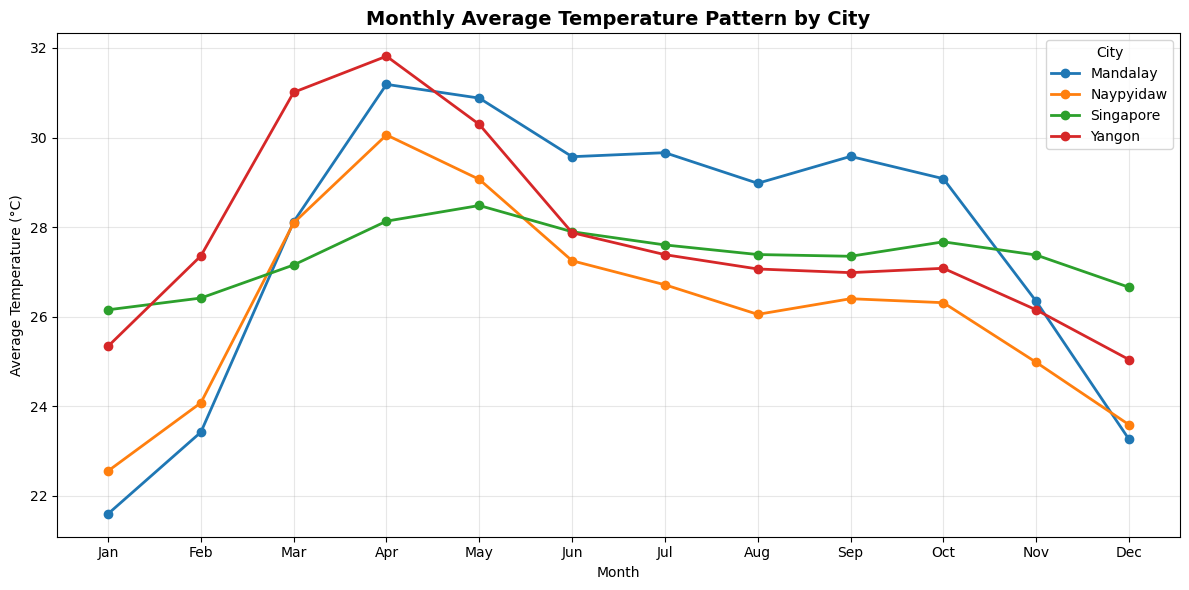

In [21]:
plt.figure(figsize=(12, 6))

for city in monthly_temperature["city"].unique():
    city_data = monthly_temperature[monthly_temperature["city"] == city]
    plt.plot(
        city_data["month_name"],
        city_data["avg_monthly_temperature"],
        marker="o",
        linewidth=2,
        label=city
    )

plt.title("Monthly Average Temperature Pattern by City", fontsize=14, fontweight="bold")
plt.xlabel("Month")
plt.ylabel("Average Temperature (°C)")
plt.legend(title="City")
plt.grid(True, alpha=0.3)
plt.tight_layout()
plt.show()

## 5.. Heat-Risk Days by City

This section compares the total number of heat-risk days across selected cities.

A heat-risk day is defined as a day where the maximum temperature is at least 35°C.

This analysis helps identify cities that are more frequently exposed to high-temperature conditions.

In [22]:
heat_risk_summary = (
    df.groupby("city", as_index=False)
      .agg(
          heat_risk_days=("heat_risk_day", "sum")
      )
      .sort_values("heat_risk_days", ascending=False)
)

heat_risk_summary

,city,heat_risk_days
0,Mandalay,980
3,Yangon,566
1,Naypyidaw,418
2,Singapore,0


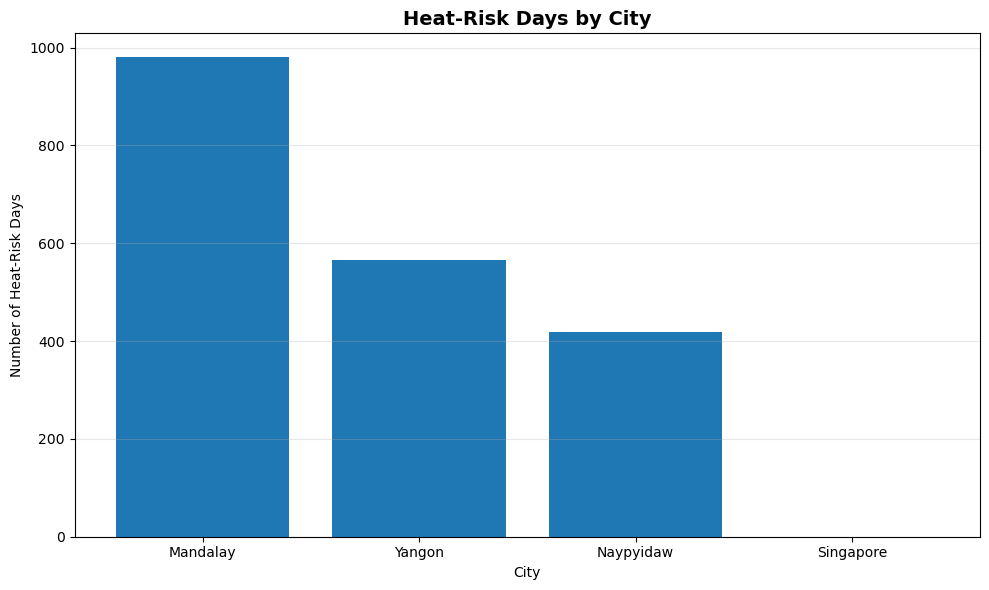

In [23]:
plt.figure(figsize=(10,6))

plt.bar(
    heat_risk_summary["city"],
    heat_risk_summary["heat_risk_days"]
)

plt.title("Heat-Risk Days by City", fontsize=14, fontweight="bold")
plt.xlabel("City")
plt.ylabel("Number of Heat-Risk Days")
plt.grid(axis="y", alpha=0.3)

plt.tight_layout()
plt.show()

## 6. Climate Risk Score Ranking by City

This section compares the average daily climate risk score across selected cities.

The climate risk score was created using heat-risk days, heavy-rain days, dry days, and very-hot days.

This plot helps identify which city has the highest overall climate-related risk exposure.

In [24]:
risk_score_summary = (
    df.groupby("city", as_index=False)
      .agg(
          avg_risk_score=("daily_climate_risk_score", "mean"),
          max_risk_score=("daily_climate_risk_score", "max"),
          high_risk_days=("risk_level", lambda x: (x == "High").sum())
      )
      .sort_values("avg_risk_score", ascending=False)
)

risk_score_summary

,city,avg_risk_score,max_risk_score,high_risk_days
0,Mandalay,26.952555,70,230
3,Yangon,19.069343,70,317
1,Naypyidaw,15.661496,70,139
2,Singapore,2.563869,30,0


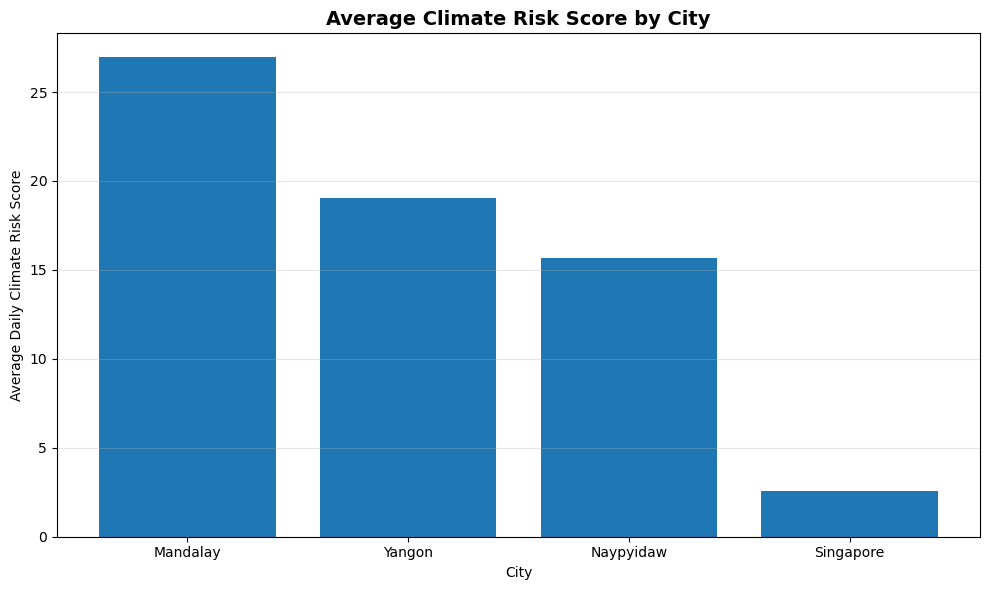

In [25]:
plt.figure(figsize=(10, 6))

plt.bar(
    risk_score_summary["city"],
    risk_score_summary["avg_risk_score"]
)

plt.title("Average Climate Risk Score by City", fontsize=14, fontweight="bold")
plt.xlabel("City")
plt.ylabel("Average Daily Climate Risk Score")
plt.grid(axis="y", alpha=0.3)

plt.tight_layout()
plt.show()

## 7. Heatmap of Average Temperature by Month and City

This section visualizes average monthly temperature across cities using a heatmap.

The heatmap helps identify hotter months, cooler months, and city-level temperature differences more clearly than a regular line chart.

In [26]:
temperature_heatmap_data = df.groupby(
    ["city", "month", "month_name"],
    as_index=False
).agg(
    avg_temperature=("temperature_avg", "mean")
)

temperature_heatmap_pivot = temperature_heatmap_data.pivot(
    index="city",
    columns="month_name",
    values="avg_temperature"
)

month_order = ["Jan", "Feb", "Mar", "Apr", "May", "Jun", 
               "Jul", "Aug", "Sep", "Oct", "Nov", "Dec"]

temperature_heatmap_pivot = temperature_heatmap_pivot[month_order]

temperature_heatmap_pivot

month_name,Jan,Feb,Mar,Apr,May,Jun,Jul,Aug,Sep,Oct,Nov,Dec
city,,,,,,,,,,,,
Mandalay,21.598871,23.422059,28.120484,31.186278,30.879194,29.571389,29.661183,28.977903,29.578167,29.080376,26.344667,23.263817
Naypyidaw,22.556344,24.077588,28.093871,30.057056,29.064892,27.248667,26.712204,26.051882,26.401167,26.312258,24.981833,23.588763
Singapore,26.153602,26.416294,27.154731,28.132778,28.482043,27.896056,27.601774,27.387312,27.348500,27.671075,27.376667,26.657527
Yangon,25.339570,27.357059,31.009140,31.814556,30.291828,27.875556,27.384570,27.065000,26.983056,27.080484,26.153167,25.043118


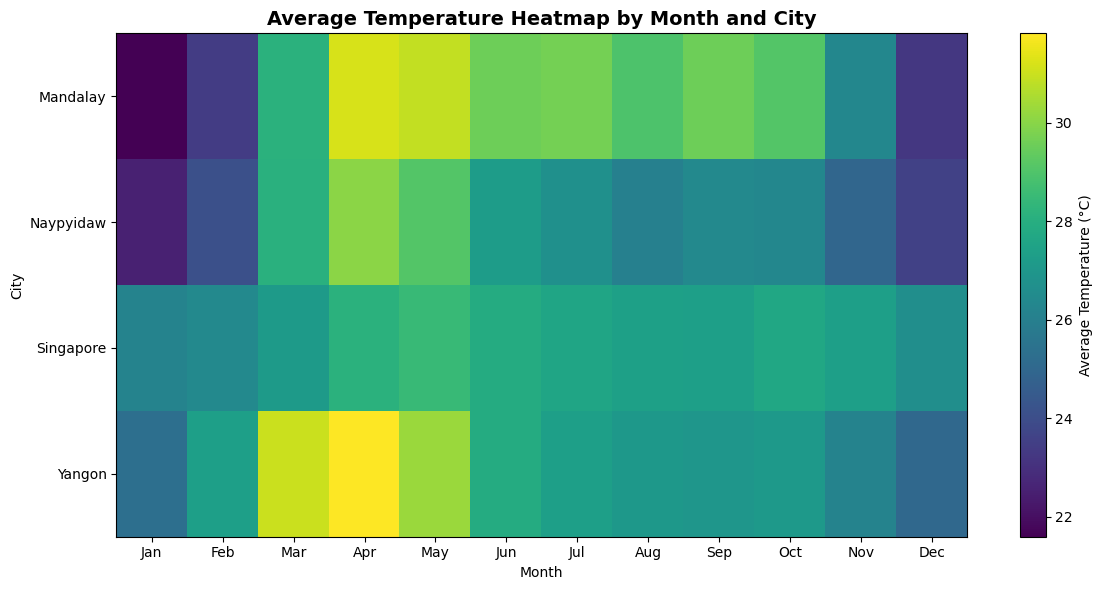

In [27]:
plt.figure(figsize=(12, 6))

plt.imshow(temperature_heatmap_pivot, aspect="auto")

plt.title("Average Temperature Heatmap by Month and City", fontsize=14, fontweight="bold")
plt.xlabel("Month")
plt.ylabel("City")

plt.xticks(
    ticks=np.arange(len(temperature_heatmap_pivot.columns)),
    labels=temperature_heatmap_pivot.columns
)

plt.yticks(
    ticks=np.arange(len(temperature_heatmap_pivot.index)),
    labels=temperature_heatmap_pivot.index
)

plt.colorbar(label="Average Temperature (°C)")

plt.tight_layout()
plt.show()

## 8. Heatmap of Average Rainfall by Month and City

This section visualizes average monthly rainfall across cities using a heatmap.

The heatmap helps identify rainy months, drier months, and city-level rainfall differences more clearly.

In [28]:
rainfall_heatmap_data = df.groupby(
    ["city", "month", "month_name"],
    as_index=False
).agg(
    avg_rainfall=("rainfall", "mean")
)

rainfall_heatmap_pivot = rainfall_heatmap_data.pivot(
    index="city",
    columns="month_name",
    values="avg_rainfall"
)

month_order = ["Jan", "Feb", "Mar", "Apr", "May", "Jun", 
               "Jul", "Aug", "Sep", "Oct", "Nov", "Dec"]

rainfall_heatmap_pivot = rainfall_heatmap_pivot[month_order]

rainfall_heatmap_pivot

month_name,Jan,Feb,Mar,Apr,May,Jun,Jul,Aug,Sep,Oct,Nov,Dec
city,,,,,,,,,,,,
Mandalay,0.281828,0.325588,0.281183,0.664889,1.985968,2.397722,1.946183,1.898817,1.905056,1.375108,0.808722,0.374570
Naypyidaw,0.097849,0.510647,0.132151,1.245500,4.226183,4.214444,5.079946,5.530323,4.659556,3.110591,1.451778,0.156022
Singapore,15.232688,11.385529,15.437903,9.257389,12.898011,11.699944,12.187204,11.821828,12.543889,13.983333,13.478722,18.916075
Yangon,0.193441,0.481706,0.226882,3.170000,8.138387,9.237278,13.876935,11.971505,13.419333,5.399731,1.989000,0.122796


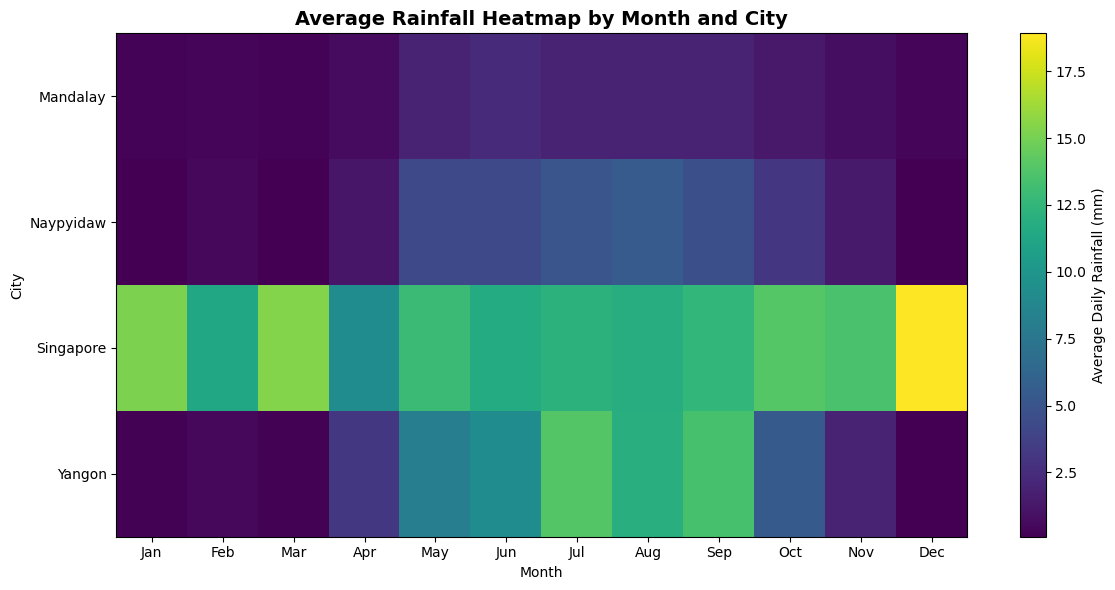

In [29]:
plt.figure(figsize=(12, 6))

plt.imshow(rainfall_heatmap_pivot, aspect="auto")

plt.title("Average Rainfall Heatmap by Month and City", fontsize=14, fontweight="bold")
plt.xlabel("Month")
plt.ylabel("City")

plt.xticks(
    ticks=np.arange(len(rainfall_heatmap_pivot.columns)),
    labels=rainfall_heatmap_pivot.columns
)

plt.yticks(
    ticks=np.arange(len(rainfall_heatmap_pivot.index)),
    labels=rainfall_heatmap_pivot.index
)

plt.colorbar(label="Average Daily Rainfall (mm)")

plt.tight_layout()
plt.show()

## 9. Rainfall Distribution by City

This section compares the distribution of daily rainfall across selected cities.

A box plot is used to show rainfall variability, median rainfall, and possible extreme rainfall days.

In [30]:
rainfall_distribution = df[["city", "rainfall"]].copy()

rainfall_distribution.head()

,city,rainfall
0,Mandalay,4.79
1,Mandalay,0.76
2,Mandalay,9.95
3,Mandalay,6.08
4,Mandalay,9.39


<Figure size 1200x600 with 0 Axes>

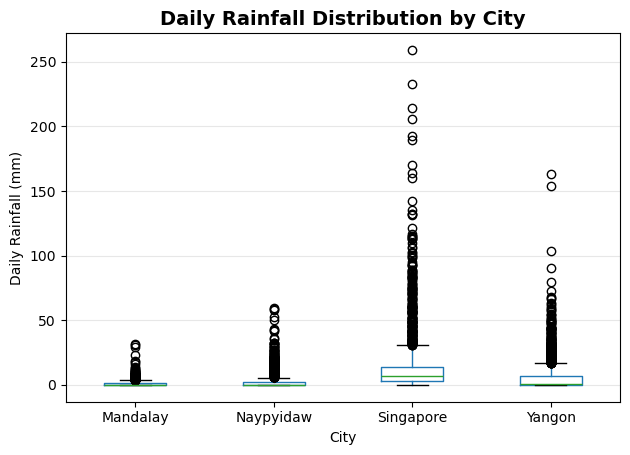

In [31]:
plt.figure(figsize=(12, 6))

df.boxplot(
    column="rainfall",
    by="city",
    grid=False
)

plt.title("Daily Rainfall Distribution by City", fontsize=14, fontweight="bold")
plt.suptitle("")
plt.xlabel("City")
plt.ylabel("Daily Rainfall (mm)")
plt.grid(axis="y", alpha=0.3)

plt.tight_layout()
plt.show()

## 10. Temperature Distribution by City

This section compares the distribution of daily maximum temperature across selected cities.

A box plot is used to show temperature variability, median temperature, and possible extreme temperature days.

In [32]:
temperature_distribution = df[["city", "temperature_max"]].copy()

temperature_distribution.head()

,city,temperature_max
0,Mandalay,29.21
1,Mandalay,30.14
2,Mandalay,26.78
3,Mandalay,27.62
4,Mandalay,26.91


<Figure size 1200x600 with 0 Axes>

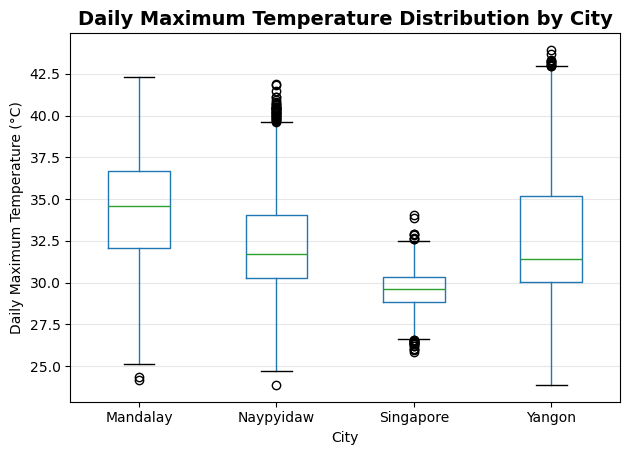

In [33]:
plt.figure(figsize=(12, 6))

df.boxplot(
    column="temperature_max",
    by="city",
    grid=False
)

plt.title("Daily Maximum Temperature Distribution by City", fontsize=14, fontweight="bold")
plt.suptitle("")
plt.xlabel("City")
plt.ylabel("Daily Maximum Temperature (°C)")
plt.grid(axis="y", alpha=0.3)

plt.tight_layout()
plt.show()

## 11. Climate Risk Level Distribution by City

This section compares the number of days classified as Low, Moderate, and High risk for each city.

A stacked bar chart is used to show how climate risk levels are distributed across cities.

In [34]:
risk_level_distribution = (
    df.groupby(["city", "risk_level"])
      .size()
      .reset_index(name="number_of_days")
)

risk_level_distribution

,city,risk_level,number_of_days
0,Mandalay,High,230
1,Mandalay,Low,1212
2,Mandalay,Moderate,750
3,Naypyidaw,High,139
4,Naypyidaw,Low,1774
5,Naypyidaw,Moderate,279
6,Singapore,Low,2192
7,Yangon,High,317
8,Yangon,Low,1626
9,Yangon,Moderate,249


In [35]:
risk_level_pivot = risk_level_distribution.pivot(
    index="city",
    columns="risk_level",
    values="number_of_days"
).fillna(0)

risk_level_pivot

risk_level,High,Low,Moderate
city,,,
Mandalay,230.0,1212.0,750.0
Naypyidaw,139.0,1774.0,279.0
Singapore,0.0,2192.0,0.0
Yangon,317.0,1626.0,249.0


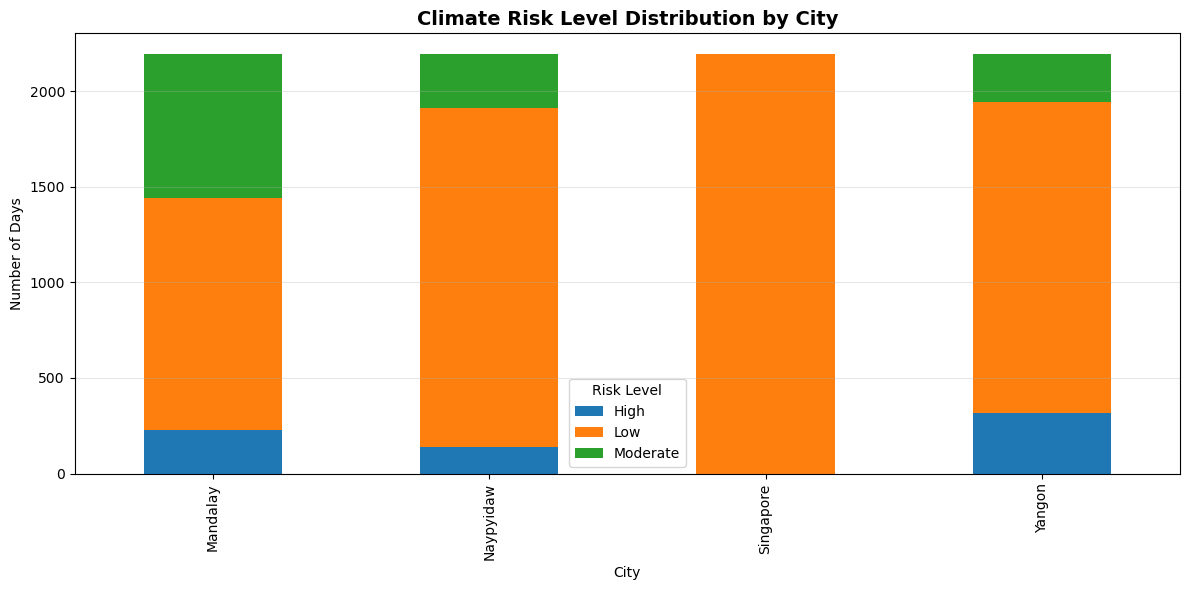

In [36]:
risk_level_pivot.plot(
    kind="bar",
    stacked=True,
    figsize=(12, 6)
)

plt.title("Climate Risk Level Distribution by City", fontsize=14, fontweight="bold")
plt.xlabel("City")
plt.ylabel("Number of Days")
plt.legend(title="Risk Level")
plt.grid(axis="y", alpha=0.3)

plt.tight_layout()
plt.show()

## 12. Correlation Matrix of Climate Variables

This section analyzes the relationship between key climate variables.

A correlation matrix is used to show whether variables move together positively, negatively, or weakly.

In [37]:
correlation_columns = [
    "temperature_avg",
    "temperature_max",
    "temperature_min",
    "rainfall",
    "humidity",
    "wind_speed",
    "solar_radiation",
    "temperature_range",
    "daily_climate_risk_score"
]

correlation_data = df[correlation_columns].copy()

correlation_data.head()

,temperature_avg,temperature_max,temperature_min,rainfall,humidity,wind_speed,solar_radiation,temperature_range,daily_climate_risk_score
0,22.56,29.21,17.90,4.79,64.14,2.21,9.34,11.31,0
1,22.87,30.14,17.65,0.76,66.13,2.17,9.82,12.49,10
2,21.56,26.78,17.90,9.95,75.17,2.04,9.07,8.88,0
3,21.44,27.62,18.01,6.08,79.23,2.31,9.21,9.61,0
4,21.10,26.91,17.26,9.39,79.46,3.25,10.89,9.65,0


In [38]:
correlation_matrix = correlation_data.corr()

correlation_matrix

,temperature_avg,temperature_max,temperature_min,rainfall,humidity,wind_speed,solar_radiation,temperature_range,daily_climate_risk_score
temperature_avg,1.000000,0.712569,0.749295,-0.009471,-0.073992,0.103783,0.270187,-0.022598,0.590566
temperature_max,0.712569,1.000000,0.082395,-0.292654,-0.685376,-0.019498,0.537477,0.680683,0.855726
temperature_min,0.749295,0.082395,1.000000,0.256697,0.554424,0.198235,-0.144024,-0.674002,0.030870
rainfall,-0.009471,-0.292654,0.256697,1.000000,0.364884,0.110515,-0.285718,-0.405622,-0.135268
humidity,-0.073992,-0.685376,0.554424,0.364884,1.000000,0.158626,-0.505848,-0.915580,-0.647847
wind_speed,0.103783,-0.019498,0.198235,0.110515,0.158626,1.000000,-0.171731,-0.160171,0.012283
solar_radiation,0.270187,0.537477,-0.144024,-0.285718,-0.505848,-0.171731,1.000000,0.504274,0.484227
temperature_range,-0.022598,0.680683,-0.674002,-0.405622,-0.915580,-0.160171,0.504274,1.000000,0.611615
daily_climate_risk_score,0.590566,0.855726,0.030870,-0.135268,-0.647847,0.012283,0.484227,0.611615,1.000000


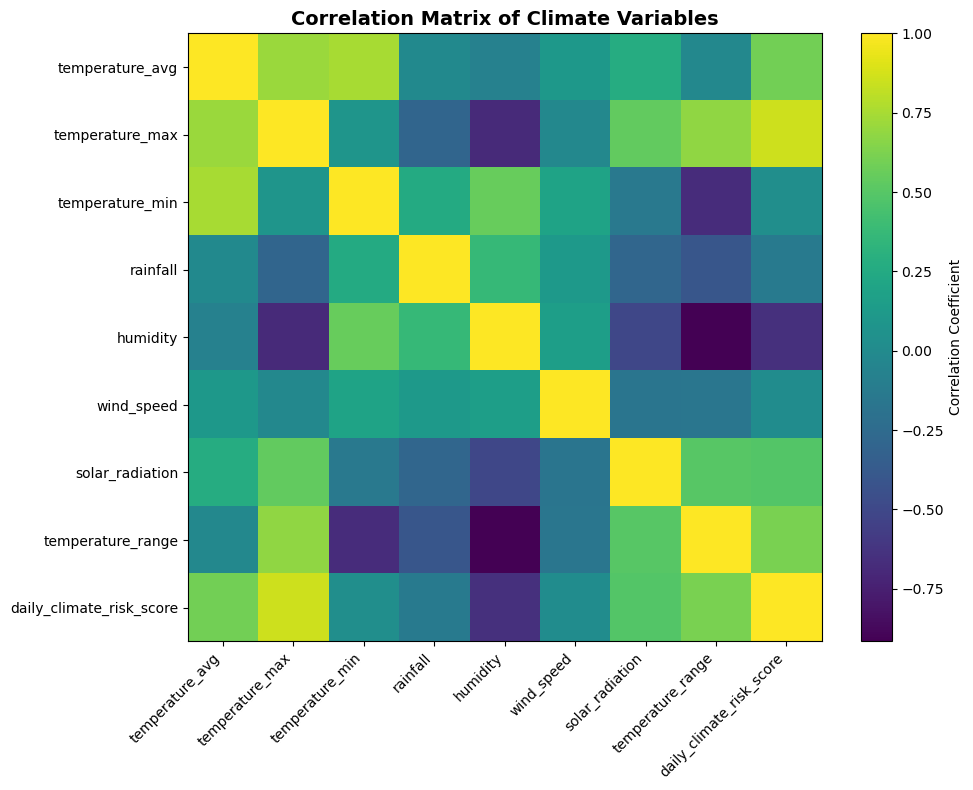

In [39]:
plt.figure(figsize=(10, 8))

plt.imshow(correlation_matrix, aspect="auto")

plt.title("Correlation Matrix of Climate Variables", fontsize=14, fontweight="bold")

plt.xticks(
    ticks=np.arange(len(correlation_matrix.columns)),
    labels=correlation_matrix.columns,
    rotation=45,
    ha="right"
)

plt.yticks(
    ticks=np.arange(len(correlation_matrix.index)),
    labels=correlation_matrix.index
)

plt.colorbar(label="Correlation Coefficient")

plt.tight_layout()
plt.show()

##  Final City-Level Climate Summary

This section creates a final summary table for each city.

The table includes key climate indicators such as average temperature, total rainfall, heat-risk days, heavy-rain days, dry days, and average climate risk score.

In [40]:
final_city_summary = (
    df.groupby("city", as_index=False)
      .agg(
          country=("country", "first"),
          avg_temperature=("temperature_avg", "mean"),
          avg_max_temperature=("temperature_max", "mean"),
          avg_min_temperature=("temperature_min", "mean"),
          max_temperature_recorded=("temperature_max", "max"),
          total_rainfall=("rainfall", "sum"),
          avg_humidity=("humidity", "mean"),
          avg_wind_speed=("wind_speed", "mean"),
          avg_solar_radiation=("solar_radiation", "mean"),
          heat_risk_days=("heat_risk_day", "sum"),
          very_hot_days=("very_hot_day", "sum"),
          heavy_rain_days=("heavy_rain_day", "sum"),
          dry_days=("dry_day", "sum"),
          avg_climate_risk_score=("daily_climate_risk_score", "mean")
      )
)

final_city_summary

,city,country,avg_temperature,avg_max_temperature,avg_min_temperature,max_temperature_recorded,total_rainfall,avg_humidity,avg_wind_speed,avg_solar_radiation,heat_risk_days,very_hot_days,heavy_rain_days,dry_days,avg_climate_risk_score
0,Mandalay,Myanmar,27.654407,34.377628,21.885607,42.31,2609.82,53.103554,2.991729,18.110324,980,278,0,1432,26.952555
1,Naypyidaw,Myanmar,26.268193,32.397609,21.110082,41.90,5579.59,63.129270,2.387381,18.312815,418,153,5,1440,15.661496
2,Singapore,Singapore,27.359758,29.600178,25.605027,34.05,29080.66,85.483955,2.823563,16.394202,0,0,114,220,2.563869
3,Yangon,Myanmar,27.781565,32.851670,23.498394,43.92,12515.62,73.147933,2.916898,17.479667,566,345,23,1157,19.069343


In [41]:
numeric_cols = final_city_summary.select_dtypes(include="number").columns

final_city_summary[numeric_cols] = final_city_summary[numeric_cols].round(2)

final_city_summary

,city,country,avg_temperature,avg_max_temperature,avg_min_temperature,max_temperature_recorded,total_rainfall,avg_humidity,avg_wind_speed,avg_solar_radiation,heat_risk_days,very_hot_days,heavy_rain_days,dry_days,avg_climate_risk_score
0,Mandalay,Myanmar,27.65,34.38,21.89,42.31,2609.82,53.10,2.99,18.11,980,278,0,1432,26.95
1,Naypyidaw,Myanmar,26.27,32.40,21.11,41.90,5579.59,63.13,2.39,18.31,418,153,5,1440,15.66
2,Singapore,Singapore,27.36,29.60,25.61,34.05,29080.66,85.48,2.82,16.39,0,0,114,220,2.56
3,Yangon,Myanmar,27.78,32.85,23.50,43.92,12515.62,73.15,2.92,17.48,566,345,23,1157,19.07


## . Rank Cities by Climate Risk

This section ranks cities based on their average climate risk score.

In [42]:
climate_risk_ranking = final_city_summary.sort_values(
    by="avg_climate_risk_score",
    ascending=False
)

climate_risk_ranking

,city,country,avg_temperature,avg_max_temperature,avg_min_temperature,max_temperature_recorded,total_rainfall,avg_humidity,avg_wind_speed,avg_solar_radiation,heat_risk_days,very_hot_days,heavy_rain_days,dry_days,avg_climate_risk_score
0,Mandalay,Myanmar,27.65,34.38,21.89,42.31,2609.82,53.10,2.99,18.11,980,278,0,1432,26.95
3,Yangon,Myanmar,27.78,32.85,23.50,43.92,12515.62,73.15,2.92,17.48,566,345,23,1157,19.07
1,Naypyidaw,Myanmar,26.27,32.40,21.11,41.90,5579.59,63.13,2.39,18.31,418,153,5,1440,15.66
2,Singapore,Singapore,27.36,29.60,25.61,34.05,29080.66,85.48,2.82,16.39,0,0,114,220,2.56


# Save Summary files

In [43]:
import os

summary_folder = "../data/processed/summary"
os.makedirs(summary_folder, exist_ok=True)

final_city_summary.to_csv("../data/processed/summary/final_city_summary.csv", index=False)
yearly_temperature.to_csv("../data/processed/summary/yearly_temperature.csv", index=False)
yearly_rainfall.to_csv("../data/processed/summary/yearly_rainfall.csv", index=False)
monthly_rainfall.to_csv("../data/processed/summary/monthly_rainfall.csv", index=False)
monthly_temperature.to_csv("../data/processed/summary/monthly_temperature.csv", index=False)
heat_risk_summary.to_csv("../data/processed/summary/heat_risk_summary.csv", index=False)
risk_score_summary.to_csv("../data/processed/summary/risk_score_summary.csv", index=False)
risk_level_distribution.to_csv("../data/processed/summary/risk_level_distribution.csv", index=False)
correlation_matrix.to_csv("../data/processed/summary/correlation_matrix.csv")

print("EDA summary files saved successfully!")

EDA summary files saved successfully!


## Notebook Summary

In this notebook, we performed exploratory data analysis on the processed climate dataset.

Completed analysis:

- Yearly average temperature trends by city
- Yearly total rainfall trends by city
- Monthly rainfall patterns
- Monthly temperature patterns
- Heat-risk days by city
- Average climate risk score ranking
- Temperature heatmap by month and city
- Rainfall heatmap by month and city
- Rainfall distribution by city
- Temperature distribution by city
- Climate risk level distribution
- Correlation matrix of climate variables
- Final city-level climate summary

The EDA results show how temperature, rainfall, and climate risk patterns differ across the selected cities.

These outputs will be used to build the Streamlit dashboard for the Climate Risk & Weather Trend Analytics Platform.